In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

In [ ]:
import matplotlib as mpl
from matplotlib import rcParams
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np

from grid_pattern_formation.evals.core import build_eval_context
from grid_pattern_formation.evals.core import compute_ratemaps
from grid_pattern_formation.evals.analysis_core import compute_grid_scores, plot_ratemaps


def editable_matplotlib():
    rcParams.update({'figure.autolayout': False})
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42
    
editable_matplotlib()

In [ ]:
grid_scores = pd.read_csv('../results/grid_scores.csv')
grid_scores

,data_source,grid_score_mean,grid_score_sds
0,Butler et al. (2019) Dataset,1.374309,0.091172
1,Banino et al. (2018) Dataset,1.307861,0.172159
2,Sorscher et al. (2023) Model,1.405457,0.083549
3,Banino et al. (2018) Model,0.944472,0.245584
4,Low-Pass Noise,0.799117,0.227837
5,replicate_baseline,1.420489,0.027177
6,Topographic Model (Ours),1.388590,0.028728


In [3]:
grid_scores = grid_scores[grid_scores['data_source'] != 'replicate_baseline']

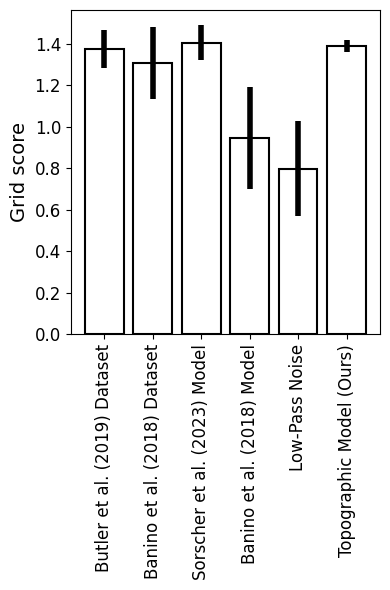

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))

ax.bar(
    grid_scores['data_source'], 
    grid_scores['grid_score_mean'], 
    yerr=grid_scores['grid_score_sds'],
    color='white',
    edgecolor='black',
    linewidth=1.5,
    error_kw={
        'linewidth': 4,
        'ecolor': 'black', 
        'capsize': 0
    }
)

ax.set_ylabel('Grid score', fontsize=14)

plt.xticks(rotation=90, fontsize=12)

plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig(
    "../results/comparative/grid_scores.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)

plt.show()

In [ ]:
sparsities_csv = pd.read_csv('../results/sparsities.csv')
sparsities_csv

,data_source,sparsity_mean,sparsity_sds
0,dataset_1,0.090543,0.055812
1,dataset_2,0.074419,0.073803
2,sorscher,0.059535,0.050855
3,banino,0.238760,0.210235
4,low_pass,0.333643,0.071314
5,replicate_baseline,0.248000,0.132665
6,topo,0.264000,0.149666


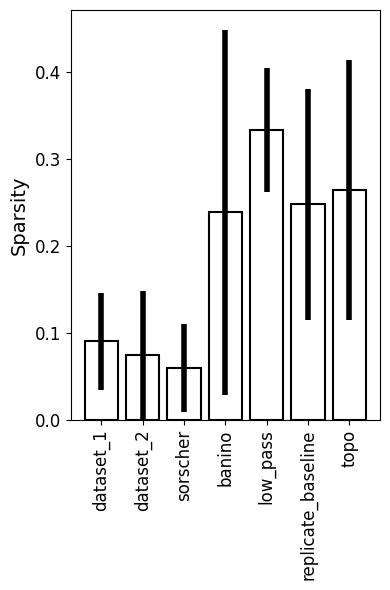

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))

ax.bar(
    sparsities_csv['data_source'], 
    sparsities_csv['sparsity_mean'], 
    yerr=sparsities_csv['sparsity_sds'],
    color='white',
    edgecolor='black',
    linewidth=1.5,
    error_kw={
        'linewidth': 4,
        'ecolor': 'black', 
        'capsize': 0
    }
)

ax.set_ylabel('Sparsity', fontsize=14)

plt.xticks(rotation=90, fontsize=12)

plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

Grid scores:   0%|          | 0/4096 [00:00<?, ?it/s]/Volumes/LaCie SSD/Documents/MurtyLab/grid-pattern-formation/grid_pattern_formation/evals/grid_scores.py:115: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))
Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 325.87it/s]


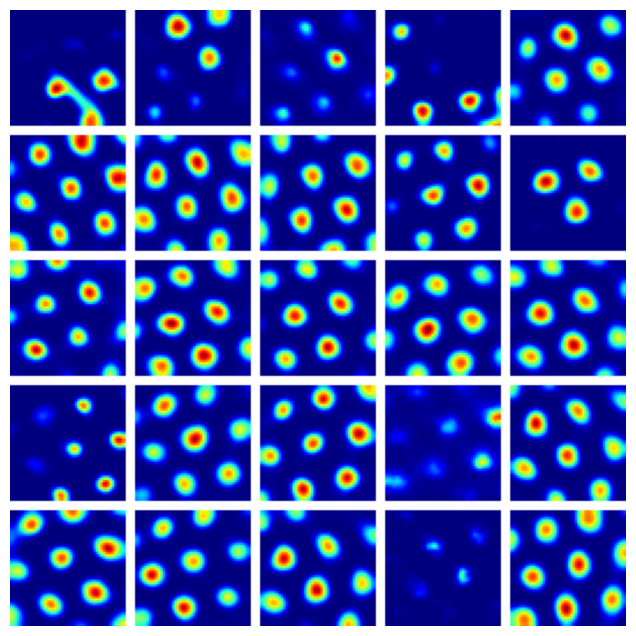

In [ ]:
baseline_ctx = build_eval_context(
    checkpoint_path="../checkpoints/replicate_baseline_colab_orig_rmsprop_alive.pth",
    config_path="../configs/replicate_baseline_colab_orig_rmsprop_alive.yaml",
    results_root="../results/comparative",
)
topo_ctx = build_eval_context(
    checkpoint_path="../checkpoints/cos_decay_hw4_final_model.pth",
    config_path="../configs/topo_cos_decay_hw4.yaml",
    results_root="../results/comparative",
)

res = 50
n_avg = 100
n_plot = 25

activations, _rate_map, _g, _pos = compute_ratemaps(
    model=baseline_ctx.model,
    trajectory_generator=baseline_ctx.trajectory_generator,
    options=baseline_ctx.options,
    res=res,
    n_avg=n_avg,
    Ng=baseline_ctx.options.Ng,
)
scores = compute_grid_scores(baseline_ctx)
score_60 = scores["score_60"]

idxs = np.flip(np.argsort(score_60))
ng = baseline_ctx.options.Ng

outputs = {}

plt.figure(figsize=(8, 8))
rm_fig = plot_ratemaps(activations[idxs], n_plot, smooth=True, width=5)
plt.imshow(rm_fig)
plt.axis("off")

plt.savefig(
    "../results/comparative/top_grid_cells_baseline.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)
plt.show()

Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 331.05it/s]


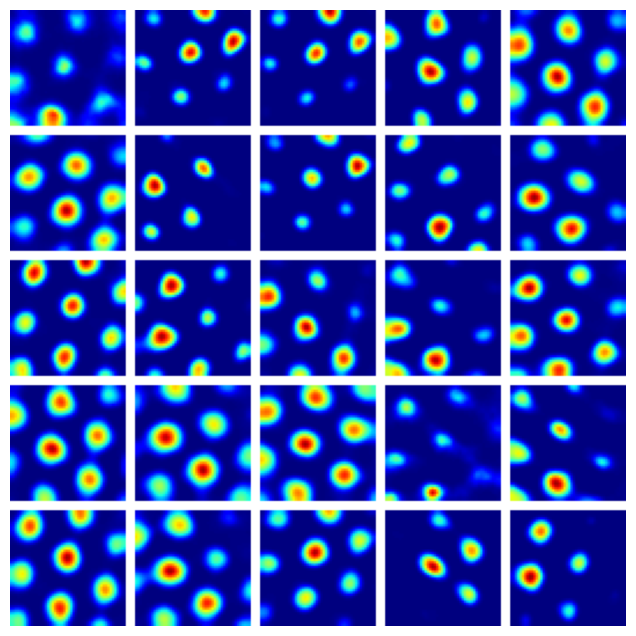

In [7]:
activations, _rate_map, _g, _pos = compute_ratemaps(
    model=topo_ctx.model,
    trajectory_generator=topo_ctx.trajectory_generator,
    options=topo_ctx.options,
    res=res,
    n_avg=n_avg,
    Ng=topo_ctx.options.Ng,
)
scores = compute_grid_scores(topo_ctx)
score_60 = scores["score_60"]

idxs = np.flip(np.argsort(score_60))
ng = topo_ctx.options.Ng

outputs = {}

plt.figure(figsize=(8, 8))
rm_fig = plot_ratemaps(activations[idxs], n_plot, smooth=True, width=5)
plt.imshow(rm_fig)
plt.axis("off")

plt.savefig(
    "../results/comparative/top_grid_cells_topo.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)
plt.show()

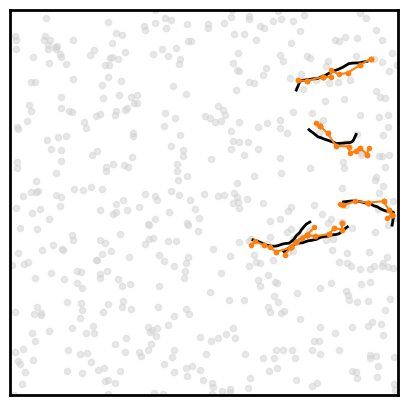

In [8]:
inputs, pos, _pc_outputs = baseline_ctx.trajectory_generator.get_test_batch()
pos = pos.detach().cpu().numpy()
pred_pos = baseline_ctx.place_cells.get_nearest_cell_pos(baseline_ctx.model.predict(inputs)).detach().cpu().numpy()
us = baseline_ctx.place_cells.us.detach().cpu().numpy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
for i in range(5):
    ax.plot(pos[:, i, 0], pos[:, i, 1], c="black", linewidth=2)
    ax.plot(pred_pos[:, i, 0], pred_pos[:, i, 1], ".-", c="C1")
ax.scatter(us[:, 0], us[:, 1], s=20, alpha=0.5, c="lightgrey")
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim([-baseline_ctx.options.box_width / 2, baseline_ctx.options.box_width / 2])
ax.set_ylim([-baseline_ctx.options.box_height / 2, baseline_ctx.options.box_height / 2])

plt.savefig(
    "../results/comparative/trajectory_baseline.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)
plt.show()

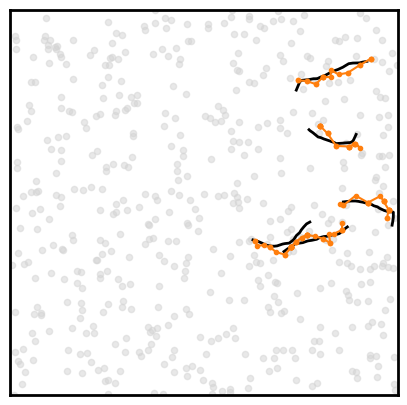

In [9]:
pred_pos = topo_ctx.place_cells.get_nearest_cell_pos(topo_ctx.model.predict(inputs)).detach().cpu().numpy()
us = topo_ctx.place_cells.us.detach().cpu().numpy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
for i in range(5):
    ax.plot(pos[:, i, 0], pos[:, i, 1], c="black", linewidth=2)
    ax.plot(pred_pos[:, i, 0], pred_pos[:, i, 1], ".-", c="C1")
ax.scatter(us[:, 0], us[:, 1], s=20, alpha=0.5, c="lightgrey")
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim([-topo_ctx.options.box_width / 2, topo_ctx.options.box_width / 2])
ax.set_ylim([-topo_ctx.options.box_height / 2, topo_ctx.options.box_height / 2])

plt.savefig(
    "../results/comparative/trajectory_topo.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)
plt.show()

In [ ]:
n_batches = 50 # 50 x 200 = 10000 trajectories
batch_size = baseline_ctx.options.batch_size

baseline_errors = []
topo_errors = []

gen = baseline_ctx.trajectory_generator.get_generator(batch_size=batch_size)

with torch.no_grad():
    for i in range(n_batches):
        inputs, pc_outputs, pos = next(gen)

        # Baseline model
        baseline_preds = baseline_ctx.model.predict(inputs)
        baseline_pred_pos = baseline_ctx.place_cells.get_nearest_cell_pos(baseline_preds)
        baseline_err = torch.sqrt(((pos - baseline_pred_pos) ** 2).sum(-1))
        baseline_errors.append(baseline_err)

        # Topographic model
        topo_preds = topo_ctx.model.predict(inputs)
        topo_pred_pos = topo_ctx.place_cells.get_nearest_cell_pos(topo_preds)
        topo_err = torch.sqrt(((pos - topo_pred_pos) ** 2).sum(-1))
        topo_errors.append(topo_err)

baseline_per_traj = torch.cat([e.mean(dim=0) for e in baseline_errors])
topo_per_traj = torch.cat([e.mean(dim=0) for e in topo_errors])

baseline_per_traj_cm = baseline_per_traj * 100
topo_per_traj_cm = topo_per_traj * 100

print(f"Average decoding error over {len(baseline_per_traj_cm)} trajectories:")
print(f"Baseline: {baseline_per_traj_cm.mean():.2f} +/- {baseline_per_traj_cm.std():.2f} cm")
print(f"Topographic: {topo_per_traj_cm.mean():.2f} +/- {topo_per_traj_cm.std():.2f} cm")

Average decoding error over 10000 trajectories:
Baseline: 5.03 +/- 1.64 cm
Topographic: 4.87 +/- 2.12 cm
